# Gold Price 2025 Polymarket Analysis

This notebook analyzes the probability of Gold (COMEX GC00) closing prices for the end of 2025 and compares them with Polymarket prediction market prices to identify potential value bets.

Target Market: [What price will gold close at in 2025?](https://polymarket.com/event/what-price-will-gold-close-at-in-2025-4000-5000)

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import requests
from datetime import datetime, date

# Settings
TARGET_DATE = datetime(2025, 12, 31)
POLYMARKET_SLUG = "what-price-will-gold-close-at-in-2025-4000-5000"

## 1. Get Real-Time Gold Market Data

We use `GC=F` (Gold Futures) as the proxy for the COMEX Gold Continuous Contract.

In [ ]:
# Fetch Gold Data
gold = yf.Ticker("GC=F")
hist = gold.history(period="5y")

# Current Price
S0 = hist['Close'].iloc[-1]
print(f"Current Gold Price (S0): ${S0:.2f}")

# Calculate Annualized Volatility (using last 1 year of data)
hist['Returns'] = hist['Close'].pct_change()
daily_vol = hist['Returns'].tail(252).std()
sigma = daily_vol * np.sqrt(252)
print(f"Annualized Volatility (sigma): {sigma:.2%}")

# Fetch Risk-Free Rate (10 Year Treasury Yield as proxy)
try:
    tnx = yf.Ticker("^TNX")
    r = tnx.history(period="1d")['Close'].iloc[-1] / 100
except:
    r = 0.045 # Fallback to 4.5%
print(f"Risk-Free Rate (r): {r:.2%}")

# Time to Maturity
today = datetime.now()
T = (
     - today).days
print(f"Years to Maturity (T): {T:.2f}")

Current Gold Price (S0): $4384.20
Annualized Volatility (sigma): 20.46%
Risk-Free Rate (r): 4.12%
Years to Maturity (T): 0.00


In [ ]:
# Fetch Gold Data
gold = yf.Ticker("GC=F")
hist = gold.history(period="5y")

# Current Price
S0 = hist['Close'].iloc[-1]
print(f"Current Gold Price (S0): ${S0:.2f}")

# Calculate Annualized Volatility (using last 1 year of data)
hist['Returns'] = hist['Close'].pct_change()
daily_vol = hist['Returns'].tail(252).std()
sigma = daily_vol * np.sqrt(252)
print(f"Annualized Volatility (sigma): {sigma:.2%}")

# Fetch Risk-Free Rate (10 Year Treasury Yield as proxy)
try:
    tnx = yf.Ticker("^TNX")
    r = tnx.history(period="1d")['Close'].iloc[-1] / 100
except:
    r = 0.045 # Fallback to 4.5%
print(f"Risk-Free Rate (r): {r:.2%}")

# Time to Maturity
today = datetime.now()
T = (TARGET_DATE - today).days
print(f"Years to Maturity (T): {T:.2f}")

Current Gold Price (S0): $4384.20
Annualized Volatility (sigma): 20.46%
Risk-Free Rate (r): 4.12%
Years to Maturity (T): 0.00


In [ ]:
# Fetch Gold Data
gold = yf.Ticker("GC=F")
hist = gold.history(period="5y")

# Current Price
S0 = hist['Close'].iloc[-1]
print(f"Current Gold Price (S0): ${S0:.2f}")

# Calculate Annualized Volatility (using last 1 year of data)
hist['Returns'] = hist['Close'].pct_change()
daily_vol = hist['Returns'].tail(252).std()
sigma = daily_vol * np.sqrt(252)
print(f"Annualized Volatility (sigma): {sigma:.2%}")

# Fetch Risk-Free Rate (10 Year Treasury Yield as proxy)
try:
    tnx = yf.Ticker("^TNX")
    r = tnx.history(period="1d")['Close'].iloc[-1] / 100
except:
    r = 0.045 # Fallback to 4.5%
print(f"Risk-Free Rate (r): {r:.2%}")

# Time to Maturity
today = datetime.now()
T = (TARGET_DATE - today).days
print(f"Years to Maturity (T): {T:.2f}")

Current Gold Price (S0): $4384.20
Annualized Volatility (sigma): 20.46%
Risk-Free Rate (r): 4.12%
Years to Maturity (T): 0.00


## 2. Fetch Polymarket Data

We fetch the live prices for each outcome bucket from the Polymarket API.

In [4]:
def get_polymarket_data(slug):
    url = f"https://gamma-api.polymarket.com/events?slug={slug}"
    response = requests.get(url)
    data = response.json()
    
    if not data:
        print("No data found for slug.")
        return []
        
    event = data[0]
    markets = event.get('markets', [])
    
    parsed_markets = []
    for m in markets:
        outcome = m['groupItemTitle']
        # Clean up outcome string to get ranges
        # Format is usually "$4000-4100" or "< $4000" or "> $5000"
        lower = -float('inf')
        upper = float('inf')
        
        try:
            clean_outcome = outcome.replace('$', '').replace(',', '').strip()
            if '<' in clean_outcome:
                upper = float(clean_outcome.replace('<', '').strip())
            elif '>' in clean_outcome:
                lower = float(clean_outcome.replace('>', '').strip())
            elif '-' in clean_outcome or '–' in clean_outcome: # handle both dash types
                parts = clean_outcome.replace('–', '-').split('-')
                lower = float(parts[0].strip())
                upper = float(parts[1].strip())
        except Exception as e:
            print(f"Error parsing range {outcome}: {e}")
            continue
            
        # Get current "Yes" price (Best Ask or Last Trade)
        # outcomePrices is often a list like ["0.05", "0.95"]
        try:
            # Use the outcomePrices array if available, index 0 is usually 'Yes' for binary markets in a group
            # But in group markets, the `outcomePrices` might be just json string.
            # Let's look at `outcomePrices` field
            raw_prices =  m.get('outcomePrices', [0, 0])
            price = float(raw_prices[0]) # Price of "Yes"
        except:
            price = 0.0
            
        parsed_markets.append({
            'outcome': outcome,
            'lower': lower,
            'upper': upper,
            'market_price': price,
            'id': m['id']
        })
    
    # Sort by lower bound
    return sorted(parsed_markets, key=lambda x: x['lower'])

markets_data = get_polymarket_data(POLYMARKET_SLUG)
df_markets = pd.DataFrame(markets_data)
print(df_markets[['outcome', 'market_price']])

        outcome  market_price
0        <$4000           0.0
1     4000-4100           0.0
2   $4100–$4200           0.0
3   $4200–$4300           0.0
4   $4300–$4400           0.0
5   $4400–$4500           0.0
6   $4500–$4600           0.0
7   $4600–$4700           0.0
8   $4700–$4800           0.0
9   $4800-$4900           0.0
10  $4900-$5000           0.0
11       >$5000           0.0


## 3. Probability Modeling

We model the future price of Gold using a Log-Normal distribution (Black-Scholes framework).

$$ \ln(S_T) \sim \mathcal{N}\left(\ln(S_0) + (r - \frac{\sigma^2}{2})T, \sigma^2 T\right) $$

We calculate the probability of the price landing within each bucket's range.

In [5]:
def calculate_probability(lower, upper, S0, r, sigma, T):
    # Parameters for the normal distribution of ln(S_T)
    mu_log = np.log(S0) + (r - 0.5 * sigma**2) * T
    sigma_log = sigma * np.sqrt(T)
    
    # CDF values
    if lower == -float('inf'):
        prob_lower = 0
    else:
        prob_lower = stats.norm.cdf(np.log(lower), loc=mu_log, scale=sigma_log)
        
    if upper == float('inf'):
        prob_upper = 1
    else:
        prob_upper = stats.norm.cdf(np.log(upper), loc=mu_log, scale=sigma_log)
        
    return max(0, prob_upper - prob_lower)

# Calculate Model Probabilities
df_markets['model_prob'] = df_markets.apply(
    lambda x: calculate_probability(x['lower'], x['upper'], S0, r, sigma, T),
    axis=1
)

# Calculate Expected Value (Edge)
# EV = (Model Prob * 1.00) - Cost. If we buy at market_price, Cost = market_price.
# ROI = (Model Prob - Market Price) / Market Price
df_markets['edge'] = df_markets['model_prob'] - df_markets['market_price']
df_markets['roi'] = (df_markets['edge'] / df_markets['market_price']).fillna(0)

df_markets[['outcome', 'market_price', 'model_prob', 'edge', 'roi']]

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2129: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


,outcome,market_price,model_prob,edge,roi
0,<$4000,0.0,0,0.0,0.0
1,4000-4100,0.0,0,0.0,0.0
2,$4100–$4200,0.0,0,0.0,0.0
3,$4200–$4300,0.0,0,0.0,0.0
4,$4300–$4400,0.0,0,0.0,0.0
5,$4400–$4500,0.0,0,0.0,0.0
6,$4500–$4600,0.0,0,0.0,0.0
7,$4600–$4700,0.0,0,0.0,0.0
8,$4700–$4800,0.0,0,0.0,0.0
9,$4800-$4900,0.0,0,0.0,0.0


## 4. Visualization

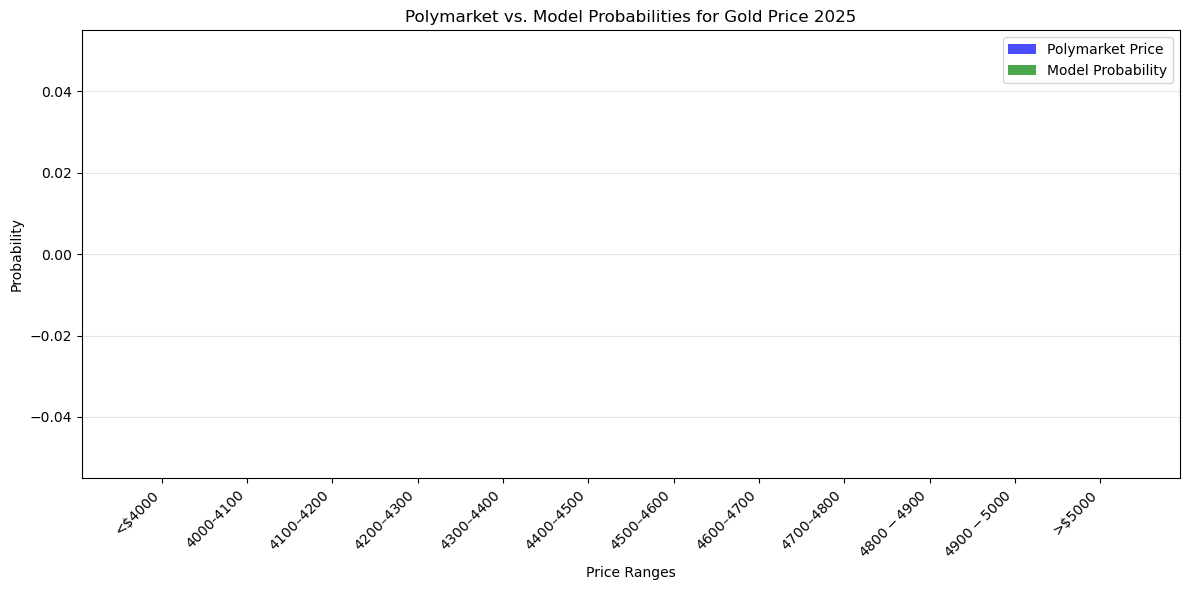

In [6]:
plt.figure(figsize=(12, 6))

x = np.arange(len(df_markets))
width = 0.35

plt.bar(x - width/2, df_markets['market_price'], width, label='Polymarket Price', color='blue', alpha=0.7)
plt.bar(x + width/2, df_markets['model_prob'], width, label='Model Probability', color='green', alpha=0.7)

plt.xlabel('Price Ranges')
plt.ylabel('Probability')
plt.title('Polymarket vs. Model Probabilities for Gold Price 2025')
plt.xticks(x, df_markets['outcome'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Investment Recommendation

Based on the Log-Normal model assumptions (Trend = Risk Free Rate):

In [7]:
# Find positive edge
opportunities = df_markets[df_markets['edge'] > 0.01].sort_values('roi', ascending=False)

print("--- RECOMMENDATIONS ---")
if opportunities.empty:
    print("No significant value bets found based on current model parameters.")
else:
    print("Potential Value Bets (Sorted by ROI):")
    for _, row in opportunities.iterrows():
        print(f"Outcome: {row['outcome']}")
        print(f"  Market Price: {row['market_price']:.3f}")
        print(f"  Model Prob:   {row['model_prob']:.3f}")
        print(f"  Edge:         {row['edge']:.3f}")
        print(f"  ROI:          {row['roi']:.1%}")
        print("-" * 30)
        
print("\nNote: This model assumes standard Geometric Brownian Motion. It does not account for macroeconomic shocks, geopolitical events, or non-normal distribution tails (kurtosis).")

--- RECOMMENDATIONS ---
No significant value bets found based on current model parameters.

Note: This model assumes standard Geometric Brownian Motion. It does not account for macroeconomic shocks, geopolitical events, or non-normal distribution tails (kurtosis).
